In [42]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


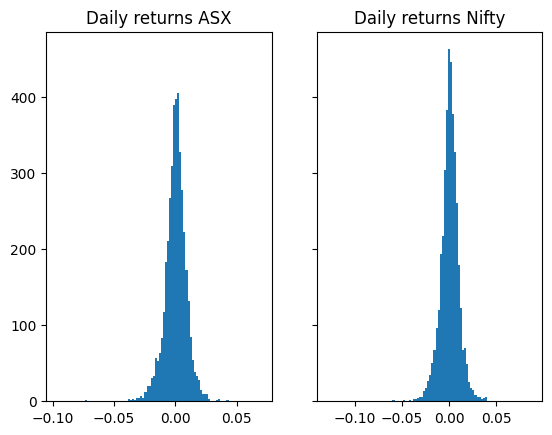

In [43]:
df = yf.download('^AXJO',start='2010-01-01')
df_nifty = yf.download("^NSEI", start="2010-01-01")
df.columns = df.columns.droplevel(1)
df_nifty.columns = df_nifty.columns.droplevel(1)
df['return'] = df['Close'].pct_change()
df_nifty['return'] = df_nifty['Close'].pct_change()
fig, ax = plt.subplots(1,2, sharey='all')
ax[0].hist(df['return'], bins = 100)
ax[1].hist(df_nifty['return'], bins= 100)
# ax[0].ylabel('frequency')
# ax[0].xlabel('return')
ax[0].title.set_text('Daily returns ASX')
ax[1].title.set_text('Daily returns Nifty')

In [44]:
print(df['return'].nlargest(3))
print(df['return'].nsmallest(3))
print(f"Kurtosis: Nifty: {df_nifty['return'].kurtosis()}; ASX: {df['return'].kurtosis()}")
print(f"Skewness: Nifty: {df_nifty['return'].skew()}; ASX: {df['return'].skew()}")
print(f"Mean: Nifty: {df_nifty['return'].mean()}; ASX: {df['return'].mean()}")

Date
2020-03-30    0.070007
2020-03-17    0.058257
2020-03-25    0.055409
Name: return, dtype: float64
Date
2020-03-16   -0.096998
2020-03-12   -0.073578
2020-03-09   -0.073292
Name: return, dtype: float64
Kurtosis: Nifty: 11.449004699151187; ASX: 8.42769638746237
Skewness: Nifty: -0.6664806151442179; ASX: -0.6578530503271899
Mean: Nifty: 0.0004301059375947341; ASX: 0.00018239806656245963


Observations:
1. Nifty fat tail is double the fat tail value of ASX.
2. But Nifty has a small positive skewness which implies the fat tail is in the positive side which compared to ASX is quite a positive thing as ASX has much greater negative skewness. I need to investigate more about it.
3. ASX mean daily return is only half the nifty. It also implies nifty fifty is growing faster.
4. From the annual volatility the mean annual volatility is same in both. It seems nifty is better than asx but there must more economical factors that I am lacking. I need to find those.
5. Nifty shows higher raw returns over 2010–present, but after adjusting for currency depreciation, risk-free rate, transaction costs, and market access — the advantage is unclear and possibly reversed for a NZ-based trader. 

In [45]:
annual_vol = df['return'].groupby(df.index.year).std()*252**0.5
annual_vol_nifty = df_nifty['return'].groupby(df_nifty.index.year).std()*252**0.5
print(f"Annual Volatility Mean: Nifty: {annual_vol_nifty.mean()}; ASX: {annual_vol.mean()}")


Annual Volatility Mean: Nifty: 0.15859026940884594; ASX: 0.14117887080487468


In [50]:
sharpe_ratio_asx = (df['return'].mean()*252 - 0.03)/(df['return'].std()*252**0.5)
sharpe_ratio_nifty = (df_nifty['return'].mean()*252 - 0.06)/(df_nifty['return'].std()*252**0.5)
print(f"Sharpe ratio: ASX: {sharpe_ratio_asx}; Nifty: {sharpe_ratio_nifty}" )

Sharpe ratio: ASX: 0.10729256954940689; Nifty: 0.2924640390153646
